### NIEJEDNORODNY PROCES POISSONA

In [74]:
import numpy as np
import scipy.stats as sc
import matplotlib.pyplot as plt

In [75]:
def l1(t):
    return np.sin(t)**2

def l2(t):
    return t**4

def l3(t):
    return np.exp(-t**2)

def l4(t):
    return t

def l5(t):
    return np.sign(np.sin(3*t)) + 1 # p = 3

def l6(t):
    return np.minimum(264, np.abs(t - 4/3))

def l7(t):
    return np.exp((2*np.sin(t/12 + 3)-0.9))**3

In [76]:
def S_1(lam, T):
    t = 0
    S_I = []
    M = np.max(lam(T))
    while True:
        U1 = np.random.random()
        dt = -1/M * np.log(U1)
        t += dt
        if t > T:
            return np.array(S_I)
        U2 = np.random.random()
        if U2 <= lam(t) / M:
            S_I.append(t)

def y_poiss(lam, t, k):
    x = np.linspace(0, t, 100)
    Lambda_t = np.trapz(lam(x), x)
    return sc.poisson.pmf(k, Lambda_t)

In [77]:
def N_t(S, t):
    return np.sum(S <= t)

### Zadanie 2

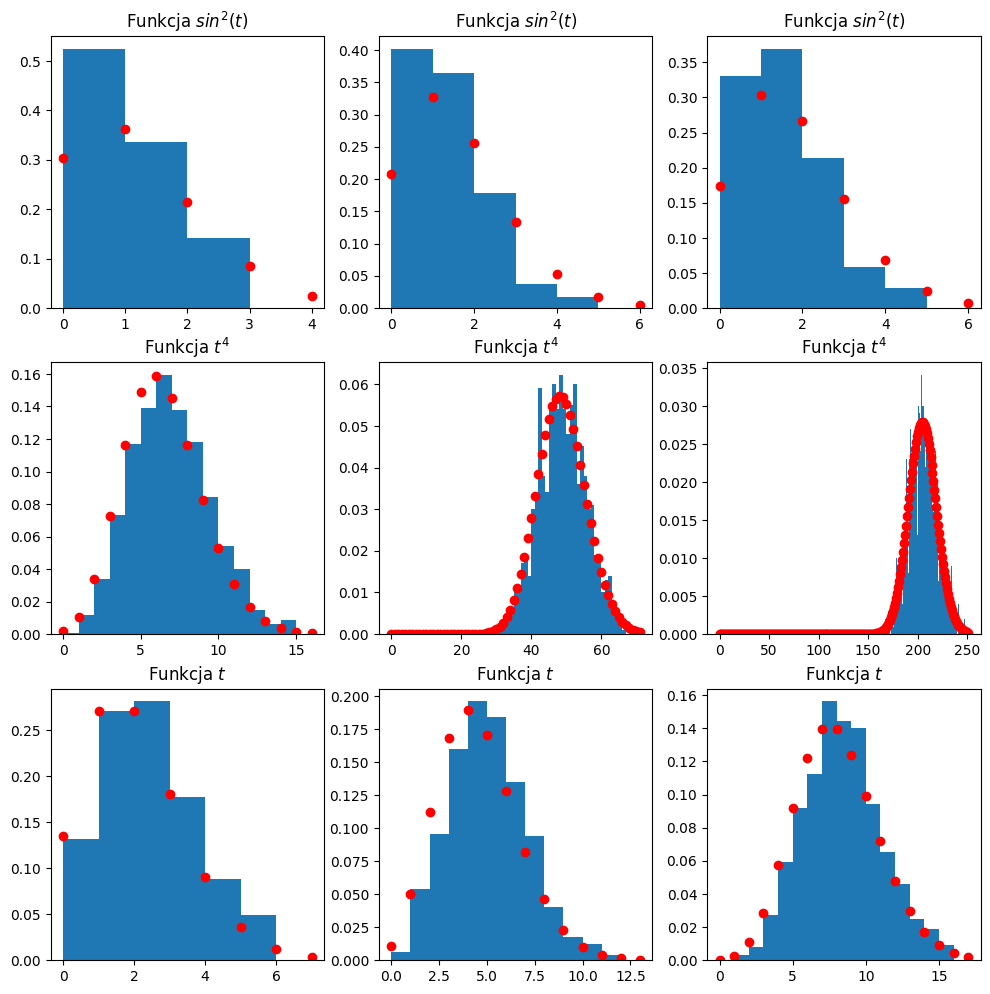

In [78]:
t_values = [2, 3, 4]
f_list = [l1, l2, l4]
fig, axs = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    S_list = []

    for p in range(1000):
        S = S_1(f_list[i], 7)
        S_list.append(S)

    for j in range(3):
        Nt_values = [N_t(np.array(s), t_values[j]) for s in S_list]
        k_values = np.arange(0, max(Nt_values)+1)
        pmf = y_poiss(f_list[i], t_values[j], k_values)
        bins = np.arange(np.min(Nt_values), np.max(Nt_values), 1)
        axs[i][j].hist(Nt_values, label='Histogram', density=True, bins=bins)
        axs[i][j].plot(k_values, pmf, 'ro', label='Rozkład Poissona Poiss($\int{\lam(s) ds}$)')

for k in range(3):
    axs[0][k].set_title('Funkcja $sin^2(t)$')
    axs[1][k].set_title('Funkcja $t^4$')
    axs[2][k].set_title('Funkcja $t$')

plt.show()


### Zadanie 3: Metoda odwrotnej dystrybunaty

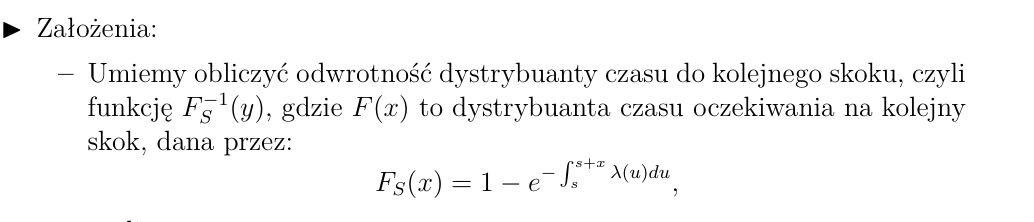

Rozwiązuje: $m(t) = \int_{0}^{t} \lambda (s) ds$

$F(t) = y = \frac{m(t)}{m(T)}$

$ t = F^{-1}(\frac{m(t)}{m(T)}) = F^{-1}(U)$

$ \lambda(t) = t^4: t = TU^\frac{1}{5}$

$\lambda(t) = t: t = T \sqrt{U}$

$\lambda(t) = sin^2(t): t = T \sqrt{U}$

In [79]:
import scipy.optimize as opt

def rev_t4(U, T):
    return T * U**(1/5)
def rev_t(U, T):
    return T * np.sqrt(U)

def sin_(t):
    return (0.5*t - 0.25* np.sin(2*t))

def rev_sin(U, T):
    t = [opt.brentq(lambda t: sin_(t)/sin_(T) - u, 0, T) for u in U] # końce przedziału
    return t

In [80]:
def S_2(M, T, t_gen):
    NT = np.random.poisson(M)
    U = np.random.random(size=NT)
    U = np.sort(U)
    t = t_gen(U, T)
    return t

[]

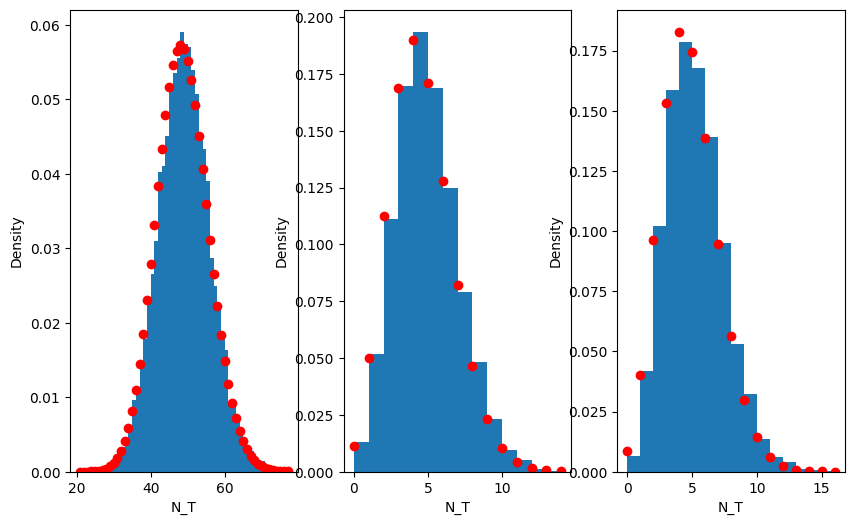

In [81]:
fig, ax = plt.subplots(1, 3, figsize=(10, 6))
T = 3

def simulate_process(M, T, rev_distr, func):
    N = 10000
    S_list = []
    for _ in range(N):
        S = S_2(M, T, rev_distr)
        S_list.append(S)
    Nt_values = [N_t(np.array(s), T) for s in S_list]
    x = np.arange(np.min(Nt_values), np.max(Nt_values) + 1, 1)
    y_theory = y_poiss(func, T, x)
    return (x, Nt_values, y_theory)

poiss_data = []
poiss_data.append(simulate_process(M=T**5/5, T=T, rev_distr=rev_t4, func=lambda t: t**4))
poiss_data.append(simulate_process(M=1/2*T**2, T=T, rev_distr=rev_t, func=lambda t: t))
T = 10
poiss_data.append(simulate_process(M=1/2*T - 1/4*np.sin(2*T), T=T, rev_distr=rev_sin, func=lambda t: np.sin(t)**2))

for k in range(3):
    x = poiss_data[k][0]
    epiric_Nt = poiss_data[k][1]
    y_theory = poiss_data[k][2]

    ax[k].hist(epiric_Nt, bins=x, density=True)
    ax[k].plot(x, y_theory, 'ro')
    ax[k].set_xlabel('N_T')
    ax[k].set_ylabel('Density')

plt.plot()


### Zadanie 4 - suma procesów Poissona

1: $\lambda(t) = t^4 + sgn(sin(\pi t)) + 1$

2: $\lambda(t) = sgn(sin(\pi t)) + min(264, |t - \frac{4}{3}|)$

3: $\lambda(t) = t^4 + min(264, |t - \frac{4}{3}|)$

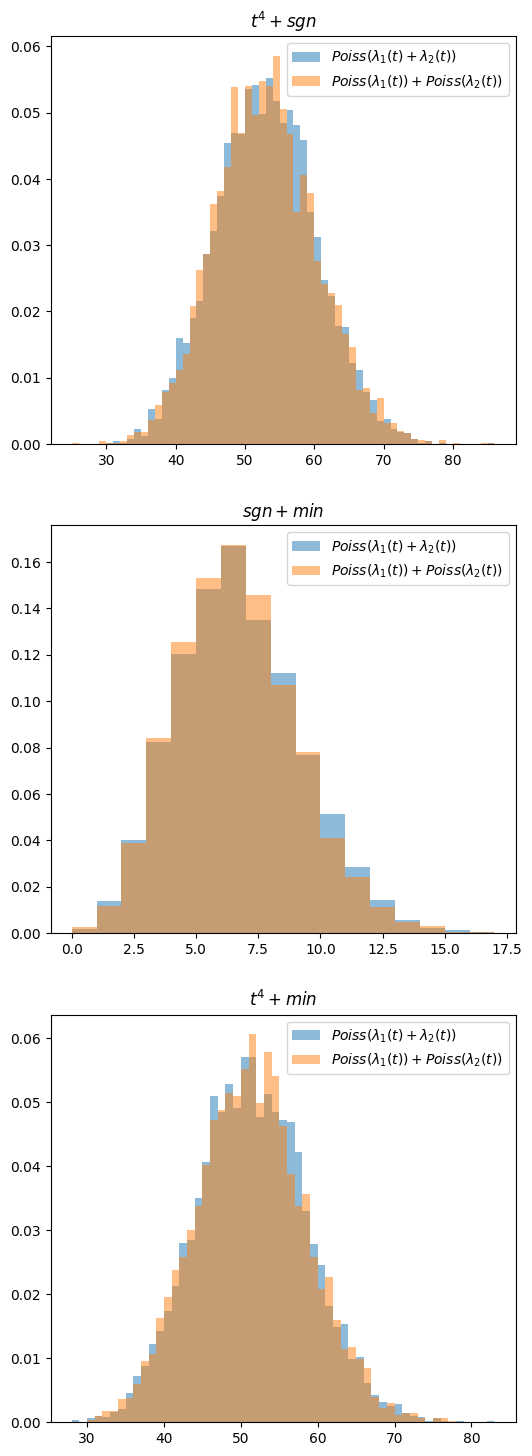

In [82]:
T = 3
N = 5000
fig, ax = plt.subplots(3, 1, figsize=(6, 18))
N1 = np.empty(N)
N2 = np.empty(N)
N3 = np.empty(N)

S1 = np.empty(N)
S2 = np.empty(N)
S3 = np.empty(N)

for i in range(N):
    Poiss1 = S_1(l2, T) # fkcja t^4
    Poiss2 = S_1(l5, T) # fkcja sgn
    Poiss3 = S_1(l6, T) # fkcja min
    N1[i] = N_t(np.concatenate([Poiss1, Poiss2]), T)
    N2[i] = N_t(np.concatenate([Poiss2, Poiss3]), T)
    N3[i] = N_t(np.concatenate([Poiss1, Poiss3]), T)
    S1[i] = N_t(S_1(lambda t: l2(t) + l5(t), T), T)
    S2[i] = N_t(S_1(lambda t: l5(t) + l6(t), T), T)
    S3[i] = N_t(S_1(lambda t: l2(t) + l6(t), T), T)

bins1 = np.arange(np.min(np.concatenate([N1, S1])), np.max(np.concatenate([N1, S1])) + 1, 1)
bins2 = np.arange(np.min(np.concatenate([N2, S2])), np.max(np.concatenate([N2, S2])) + 1, 1)
bins3 = np.arange(np.min(np.concatenate([N3, S3])), np.max(np.concatenate([N3, S3])) + 1, 1)

S_list = [S1, S2, S3]
N_list = [N1, N2, N3]
bins_list = [bins1, bins2, bins3]
for k in range(3):
    ax[k].hist(N_list[k], bins_list[k], density=True, alpha=0.5, label='$Poiss(\lambda_{1}(t) + \lambda_{2}(t))$')
    ax[k].hist(S_list[k], bins_list[k], density=True, alpha=0.5, label='$Poiss(\lambda_{1}(t)) + Poiss(\lambda_{2}(t))$')
    ax[k].legend()
ax[0].set_title('$t^4 + sgn$')
ax[1].set_title('$sgn + min$')
ax[2].set_title('$t^4 + min$')
plt.show()


### Zadanie 5 - Estymator funkcji charaktetystycznej
Funkcja charakterystyczna $\phi(t) = E[exp(itX)]$


In [83]:
def characteristic(X, t):
    Y = np.exp(t*X*1j)
    return np.mean(Y)

def normal_char(t):
    return np.exp(-0.5*t**2)

def cauchy_char(t):
    return np.exp(-np.abs(t))

def exp_char(t, lam):
    return (1-1j*t/lam)**(-1)

def poiss_char(t, lam):
    return np.exp( lam*(np.exp(1j*t) - 1))

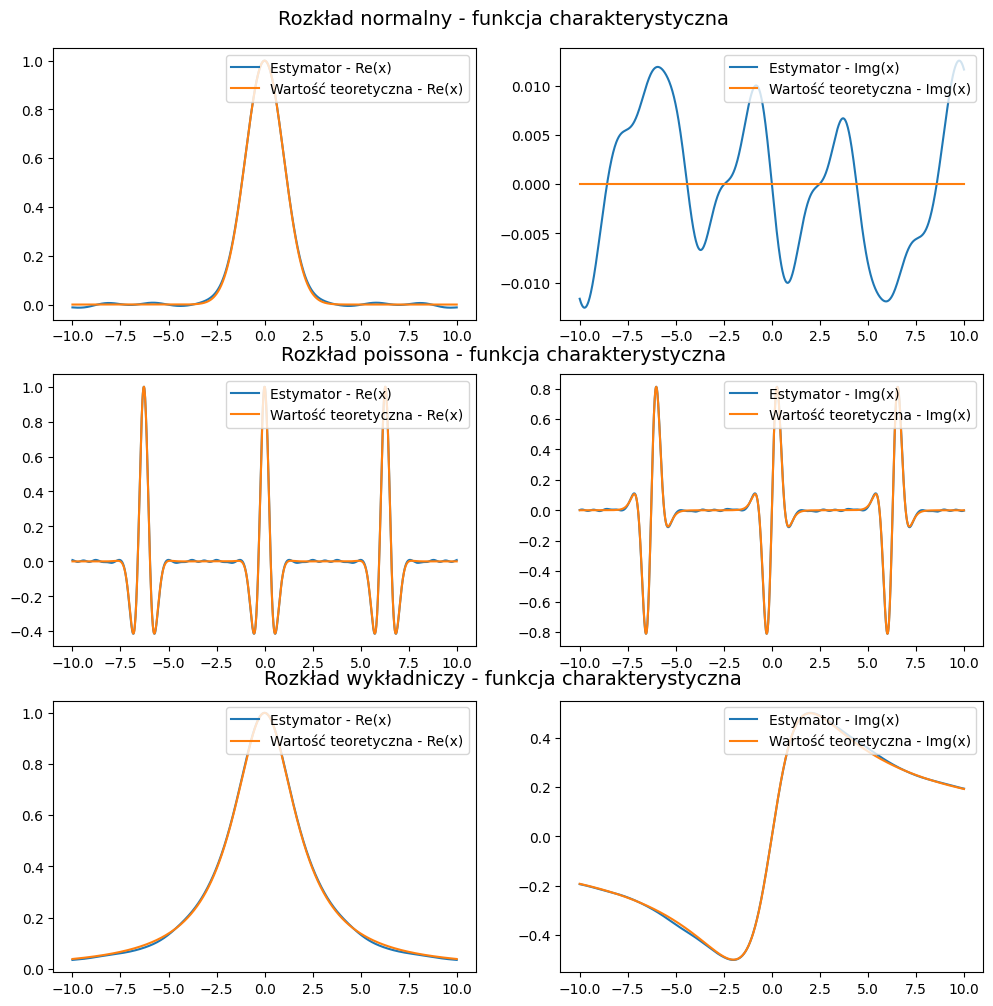

In [84]:
N = 10000
X_normal = np.random.normal(size=N)
X_poiss = np.random.poisson(size=N, lam=5)
X_exp = np.random.exponential(size=N, scale=1/2)
X = [X_normal, X_poiss, X_exp]
t = np.linspace(-10, 10, 1000)

fig, axs = plt.subplots(3, 2, figsize=(12, 12))
y_1 = normal_char(t)
y_2 = poiss_char(t, 5)
y_3 = exp_char(t, 2)

Y = [y_1, y_2, y_3]

for i in range(3):
    y_emp = [characteristic(X[i], ti) for ti in t]
    y2 = normal_char(t)
    axs[i][0].plot(t, np.real(y_emp), label='Estymator - Re(x)')
    axs[i][0].plot(t, np.real(Y[i]), label='Wartość teoretyczna - Re(x)')
    axs[i][1].plot(t, np.imag(y_emp), label='Estymator - Img(x)')
    axs[i][1].plot(t, np.imag(Y[i]), label='Wartość teoretyczna - Img(x)')
    axs[i][0].legend(loc='upper right')
    axs[i][1].legend(loc='upper right')

fig.text(0.5, 0.90, 'Rozkład normalny - funkcja charakterystyczna', ha='center', fontsize=14)
fig.text(0.5, 0.62, 'Rozkład poissona - funkcja charakterystyczna', ha='center', fontsize=14)
fig.text(0.5, 0.35, 'Rozkład wykładniczy - funkcja charakterystyczna', ha='center', fontsize=14)
plt.show()

### dodać te dodatkowe rozkłady sin, itp

### Zadanie 6 - Złożony Proces Poisssona
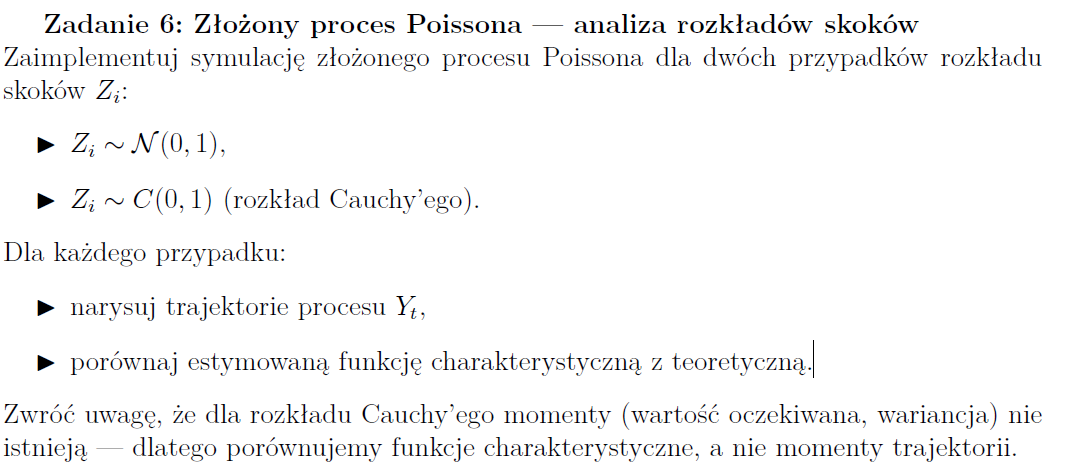

Wzór na funkcję charakterystyczną złożonego procesu Poissona:

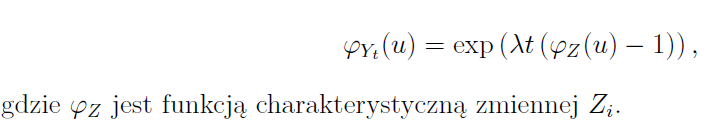

In [85]:
def poiss_Yt(Z):
    return np.cumsum(Z)

def theory_char(char_z, t, lamt):
    return np.exp(lamt*(char_z(t) - 1))

[]

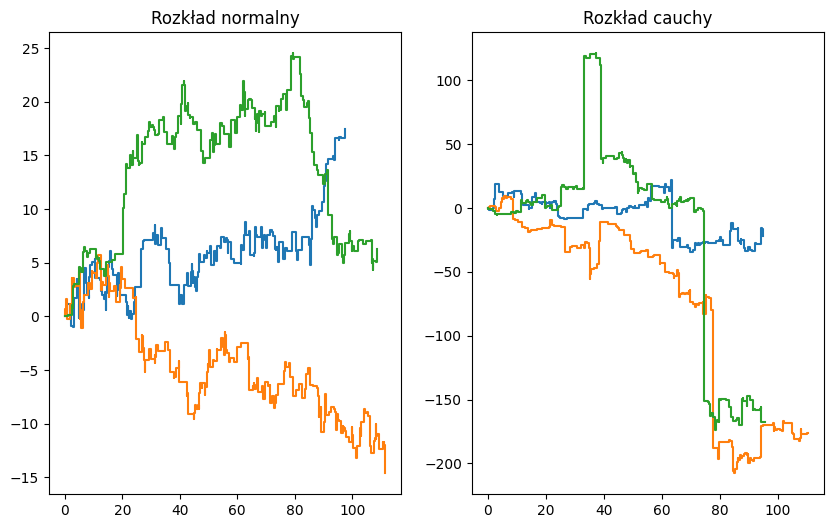

In [86]:
T = 100
lam = 2

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
for i in range(3):
    N1 = int(np.random.poisson(lam*T))
    N2 = int(np.random.poisson(lam*T))
    Z1 = np.concatenate(([0], np.random.normal(size=N1)))
    Z2 = np.concatenate(([0], np.random.standard_cauchy(size=N2)))
    t1 = np.cumsum(np.random.exponential(1/lam, N1))
    t2 = np.cumsum(np.random.exponential(1/lam, N2))
    t1 = np.concatenate(([0], t1))
    t2 = np.concatenate(([0], t2))
    y1 = poiss_Yt(Z1)
    y2 = poiss_Yt(Z2)
    ax[0].step(t1, y1, where='post')
    ax[1].step(t2, y2, where='post')

ax[0].set_title('Rozkład normalny')
ax[1].set_title('Rozkład cauchy')
plt.plot()


[(-0.004990202727999684-0.004593029726614667j), (-0.006906025776290807-0.00320698796678599j), (-0.00796737313014723-0.0030362556340605825j), (-0.007994457250824644-0.003690343311566222j), (-0.006981160124636731-0.004820301935820109j), (-0.005102958085806513-0.006166826758708999j), (-0.0026900089955534147-0.007581065957668155j), (-0.00016825949259953265-0.00901703811349908j), (0.002021381538220842-0.010500764857072185j), (0.0035103151424337614-0.01208588037000806j), (0.00407816623719414-0.01380765878381725j), (0.0037010555709694835-0.015646785336485624j), (0.0025611405539896523-0.017511115703918435j), (0.0010141771433139386-0.019238979539571037j), (-0.0004793358548324482-0.020622447742001306j), (-0.001446043311910132-0.0214445710632076j), (-0.0014961940671283757-0.021521828377238428j), (-0.00040507448931987076-0.02074237025392014j), (0.0018371124129675494-0.019092066727053814j), (0.005016830873952945-0.016663367524527253j), (0.008731480464235738-0.01364575805947575j), (0.012458757664689

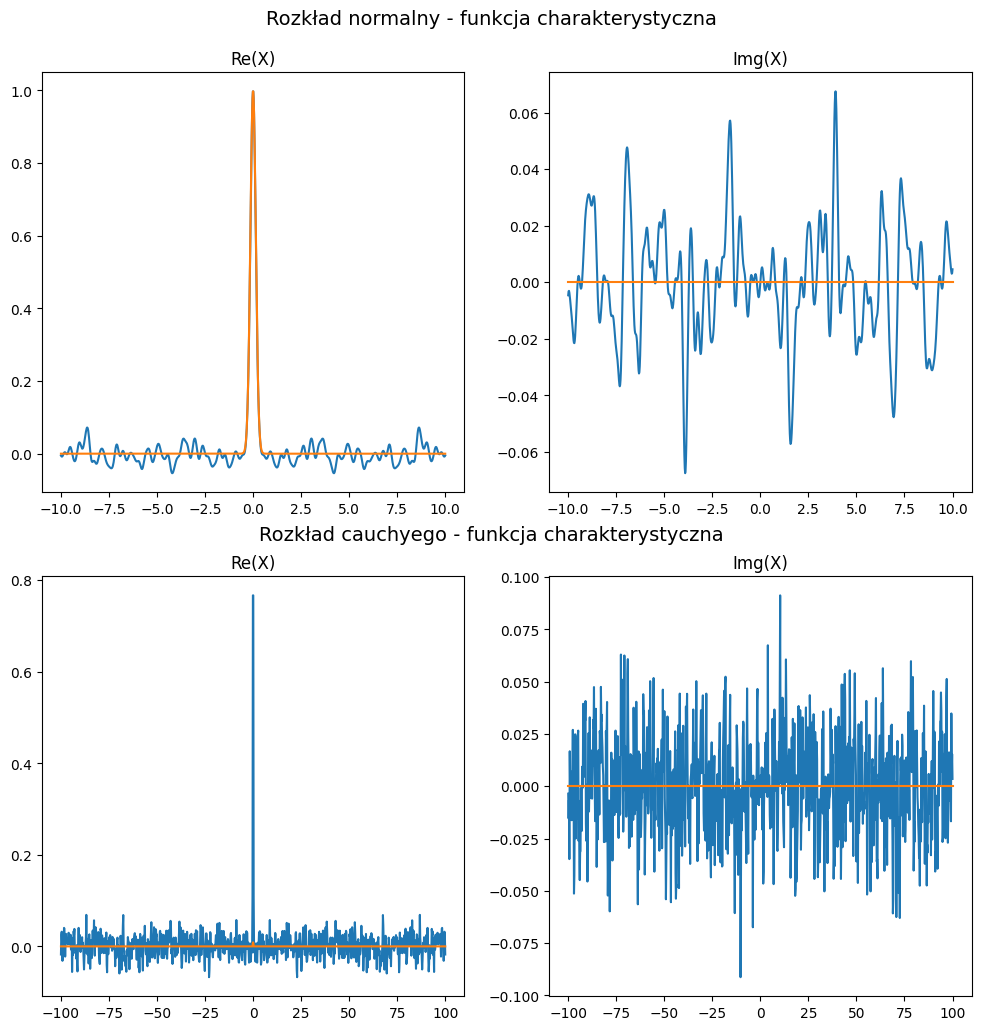

0.09612657355970308
-3.9534149972828536


In [93]:
t1 = np.linspace(-10, 10, 1000)
t2 = np.linspace(-100, 100, 1000)
Y1_emp = np.empty(1000)
Y2_emp = np.empty(1000)

for k in range(1000):
    Nt = np.random.poisson(50)
    Z1 = np.random.normal(size=Nt)
    Z2 = np.random.standard_cauchy(size=Nt)
    Y1_emp[k] = np.sum(Z1)
    Y2_emp[k] = np.sum(Z2)

fig, ax = plt.subplots(2, 2, figsize=(12, 12))
char1_emp = [characteristic(Y1_emp, ti) for ti in t1]
char2_emp = [characteristic(Y1_emp, ti) for ti in t2]

print(char1_emp)
print(len(char1_emp))

y1_theory = theory_char(normal_char, t1, 50)
y2_theory = theory_char(cauchy_char, t2, 50)
ax[0][0].plot(t1, np.real(char1_emp))
ax[0][0].plot(t1, np.real(y1_theory))
ax[0][1].plot(t1, np.imag(char1_emp))
ax[0][1].plot(t1, np.imag(y1_theory))
ax[0][0].set_title('Re(X)')
ax[0][1].set_title('Img(X)') 
ax[1][0].plot(t2, np.real(char2_emp))
ax[1][0].plot(t2, np.real(y2_theory))
ax[1][1].plot(t2, np.imag(char2_emp))
ax[1][1].plot(t2, np.imag(y2_theory))
ax[1][0].set_title('Re(X)')
ax[1][1].set_title('Img(X)')

fig.text(0.5, 0.92, 'Rozkład normalny - funkcja charakterystyczna', ha='center', fontsize=14)
fig.text(0.5, 0.49, 'Rozkład cauchyego - funkcja charakterystyczna', ha='center', fontsize=14)
plt.show()

print(np.mean(Y1_emp))
print(np.mean(Y2_emp))

### Zadanie 7: Prosty proces ryzyka

In [94]:
def balance(r0, c, t):
    Nt = np.random.poisson(1 * t) # ilość skoków do czasu t
    if Nt == 0: return False
    Z = np.random.exponential(1, size=Nt) # generowanie skoków
    Yt = np.cumsum(Z) # złożony proces Poissona
    S = np.random.uniform(0, t, size=Nt)
    S = np.sort(S) # generowanie czasów skoków

    R = r0 + c*S - Yt
    R_min = np.min(R)
    if R_min < 0:
        return True
    return False

r0 = 5
c = 0.5
t = [1, 3, 5]
b1 = 0
b2 = 0
b3 = 0
N = 1000
for _ in range(N):
    b1 += balance(r0, c, 1)
    b2 += balance(r0, c, 3)
    b3 += balance(r0, c, 5)

print(f'Probability of insolvency for t = 1: {np.round(b1/N, 3)}')  
print(f'Probability of insolvency for t = 3: {np.round(b2/N, 3)}')  
print(f'Probability of insolvency for t = 5: {np.round(b3/N, 3)}')  


Probability of insolvency for t = 1: 0.012
Probability of insolvency for t = 3: 0.097
Probability of insolvency for t = 5: 0.215
